In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx          # solo para dibujar y, más adelante, generar redes grandes
import heapq, time
from collections import deque

SEED = 42
rng = np.random.default_rng(SEED)   # reproducibilidad de los parámetros
print("Librerías cargadas. Semilla:", SEED)

Librerías cargadas. Semilla: 42


In [2]:
# (id, nombre, zona, x, y)
estaciones = [
    ("RMP",     "Recepción materia prima",   "Recepción",     5,  50),
    ("ALM_MP",  "Almacén materia prima",     "Recepción",    12,  38),
    ("CORTE",   "Corte",                     "Procesamiento",24,  52),
    ("MEC1",    "Mecanizado 1",              "Procesamiento",33,  62),
    ("MEC2",    "Mecanizado 2",              "Procesamiento",33,  42),
    ("PINT",    "Pintura / acabado",         "Procesamiento",40,  28),
    ("BUFF",    "Pulmón intermedio",         "Almacenamiento",28, 72),
    ("SUBENS",  "Subensamblaje",             "Ensamblaje",   46,  56),
    ("ENS1",    "Ensamblaje 1",              "Ensamblaje",   56,  58),
    ("ENS2",    "Ensamblaje 2",              "Ensamblaje",   54,  44),
    ("INSP1",   "Inspección 1",              "Inspección",   68,  56),
    ("INSP2",   "Inspección final",          "Inspección",   74,  46),
    ("RETR",    "Retrabajo",                 "Retrabajo",    60,  32),
    ("ALM_INT", "Almacén intermedio",        "Almacenamiento",58, 70),
    ("EMP",     "Empaque",                   "Despacho",     82,  52),
    ("DESP",    "Despacho",                  "Despacho",     92,  50),
]

pos = {e[0]: (e[3], e[4]) for e in estaciones}     # coordenadas por nodo
zona = {e[0]: e[2] for e in estaciones}
nombre = {e[0]: e[1] for e in estaciones}
nodos = [e[0] for e in estaciones]

print(f"{len(nodos)} estaciones en {len(set(zona.values()))} zonas funcionales")

16 estaciones en 7 zonas funcionales


In [3]:
# Aristas dirigidas: (origen, destino)  -- cintas transportadoras
aristas = [
    ("RMP","ALM_MP"), ("RMP","CORTE"), ("ALM_MP","CORTE"), ("ALM_MP","BUFF"),
    ("CORTE","MEC1"), ("CORTE","MEC2"), ("BUFF","CORTE"), ("BUFF","SUBENS"),
    ("MEC1","SUBENS"), ("MEC2","SUBENS"), ("MEC2","PINT"), ("PINT","ENS2"),
    ("SUBENS","ENS1"), ("SUBENS","ENS2"), ("SUBENS","ALM_INT"),
    ("ALM_INT","ENS1"), ("ALM_INT","EMP"),
    ("ENS1","INSP1"), ("ENS2","INSP1"), ("ENS1","INSP2"), ("INSP1","INSP2"),
    ("INSP1","RETR"), ("INSP2","RETR"), ("INSP2","EMP"),
    ("RETR","MEC1"), ("RETR","ENS2"),
    ("EMP","DESP"), ("EMP","BUFF"), ("DESP","ALM_INT"),
    ("ALM_INT","ALM_MP"), ("ALM_MP","RMP"),
]

def dist_eucl(u, v):
    (xu,yu),(xv,yv) = pos[u], pos[v]
    return float(np.hypot(xu-xv, yu-yv))

filas = []
for (u, v) in aristas:
    d  = dist_eucl(u, v)
    # La >= distancia: se añade un sobre-recorrido (curvas/desvíos) y se acota a [10, 80]
    La = round(min(80.0, max(10.0, d * (1.0 + rng.uniform(0.05, 0.25)))), 1)
    La = max(La, round(d, 1))                      # garantiza La >= ||pi - pj||
    Ca = round(float(rng.uniform(20, 100)), 1)     # capacidad nominal [20,100]
    Qa = round(float(rng.uniform(0.30, 0.85) * Ca), 2)  # flujo 0.3Ca <= Qa <= 0.85Ca
    ca = round(50*La + 20*Ca, 2)                   # costo de modernización
    filas.append({"origen":u, "destino":v, "dist":round(d,2),
                  "La":La, "Ca":Ca, "Qa":Qa, "rho":round(Qa/Ca,3), "ca":ca})

E = pd.DataFrame(filas)

# Estructura de adyacencia para los algoritmos (peso = La)
ady = {n: [] for n in nodos}
for _, r in E.iterrows():
    ady[r["origen"]].append((r["destino"], r["La"]))

C_total = E["ca"].sum()
B0 = 0.3 * C_total
print(f"{len(E)} cintas | Costo total modernización = {C_total:,.2f} u.m. | B0 (30%) = {B0:,.2f} u.m.")

31 cintas | Costo total modernización = 74,161.00 u.m. | B0 (30%) = 22,248.30 u.m.


In [4]:
def es_fuertemente_conexa(nodos, ady):
    # BFS desde nodos[0] sobre G y sobre G invertido; si ambos alcanzan todo -> fuertemente conexa
    def bfs(adj, ini):
        vis, q = {ini}, deque([ini])
        while q:
            x = q.popleft()
            for (y, _) in adj[x]:
                if y not in vis:
                    vis.add(y); q.append(y)
        return vis
    ady_inv = {n: [] for n in nodos}
    for u in ady:
        for (v, w) in ady[u]:
            ady_inv[v].append((u, w))
    ini = nodos[0]
    return (len(bfs(ady, ini)) == len(nodos)) and (len(bfs(ady_inv, ini)) == len(nodos))

print("="*55)
print("VALIDACIÓN DE LA RED BASE")
print("="*55)
print(f"[{'OK' if len(nodos)>=15 else 'X'}] Estaciones >= 15:        {len(nodos)}")
print(f"[{'OK' if len(E)>=25 else 'X'}] Cintas dirigidas >= 25:  {len(E)}")
print(f"[{'OK' if len(set(zona.values()))>=4 else 'X'}] Zonas funcionales >= 4:  {len(set(zona.values()))}")
sc = es_fuertemente_conexa(nodos, ady)
print(f"[{'OK' if sc else 'X'}] Fuertemente conexa:      {sc}")
ok_La  = bool((E["La"] >= E["dist"]).all())
ok_Lar = bool(((E["La"]>=10)&(E["La"]<=80)).all())
ok_Ca  = bool(((E["Ca"]>=20)&(E["Ca"]<=100)).all())
ok_Qa  = bool(((E["Qa"]>=0.3*E["Ca"]-1e-6)&(E["Qa"]<=0.85*E["Ca"]+1e-6)).all())
print(f"[{'OK' if ok_La else 'X'}] La >= distancia euclidiana")
print(f"[{'OK' if ok_Lar else 'X'}] 10 <= La <= 80")
print(f"[{'OK' if ok_Ca else 'X'}] 20 <= Ca <= 100")
print(f"[{'OK' if ok_Qa else 'X'}] 0.3Ca <= Qa <= 0.85Ca")

# Pares origen-destino (>= 4)
pares_OD = [("RMP","DESP"), ("CORTE","INSP2"), ("ALM_MP","EMP"), ("MEC1","DESP"), ("RMP","EMP")]
print(f"[{'OK' if len(pares_OD)>=4 else 'X'}] Pares origen-destino >= 4: {len(pares_OD)}")

VALIDACIÓN DE LA RED BASE
[OK] Estaciones >= 15:        16
[OK] Cintas dirigidas >= 25:  31
[OK] Zonas funcionales >= 4:  7
[OK] Fuertemente conexa:      True
[OK] La >= distancia euclidiana
[OK] 10 <= La <= 80
[OK] 20 <= Ca <= 100
[OK] 0.3Ca <= Qa <= 0.85Ca
[OK] Pares origen-destino >= 4: 5


In [5]:
tabla_estaciones = pd.DataFrame(
    [(e[0], e[1], e[2], e[3], e[4]) for e in estaciones],
    columns=["ID","Estación","Zona","x","y"])
print("ESTACIONES:"); display(tabla_estaciones)
print("\nCINTAS (aristas):"); display(E)

tabla_estaciones.to_csv("estaciones.csv", index=False)
E.to_csv("cintas.csv", index=False)

ESTACIONES:


,ID,Estación,Zona,x,y
0,RMP,Recepción materia prima,Recepción,5,50
1,ALM_MP,Almacén materia prima,Recepción,12,38
2,CORTE,Corte,Procesamiento,24,52
3,MEC1,Mecanizado 1,Procesamiento,33,62
4,MEC2,Mecanizado 2,Procesamiento,33,42
5,PINT,Pintura / acabado,Procesamiento,40,28
6,BUFF,Pulmón intermedio,Almacenamiento,28,72
7,SUBENS,Subensamblaje,Ensamblaje,46,56
8,ENS1,Ensamblaje 1,Ensamblaje,56,58
9,ENS2,Ensamblaje 2,Ensamblaje,54,44



CINTAS (aristas):


,origen,destino,dist,La,Ca,Qa,rho,ca
0,RMP,ALM_MP,13.89,16.7,55.1,42.55,0.772,1937.0
1,RMP,CORTE,19.10,22.7,27.5,23.01,0.837,1685.0
2,ALM_MP,CORTE,18.44,22.2,82.9,30.71,0.370,2768.0
3,ALM_MP,BUFF,37.58,42.8,49.7,40.24,0.810,3134.0
4,CORTE,MEC1,13.45,15.9,85.8,46.66,0.544,2511.0
5,CORTE,MEC2,13.45,14.7,64.4,21.58,0.335,2023.0
6,BUFF,CORTE,20.40,24.8,70.5,50.54,0.717,2650.0
7,BUFF,SUBENS,24.08,27.0,97.7,77.30,0.791,3304.0
8,MEC1,SUBENS,14.32,17.3,35.6,19.82,0.557,1577.0
9,MEC2,SUBENS,19.10,20.2,32.3,21.82,0.676,1656.0


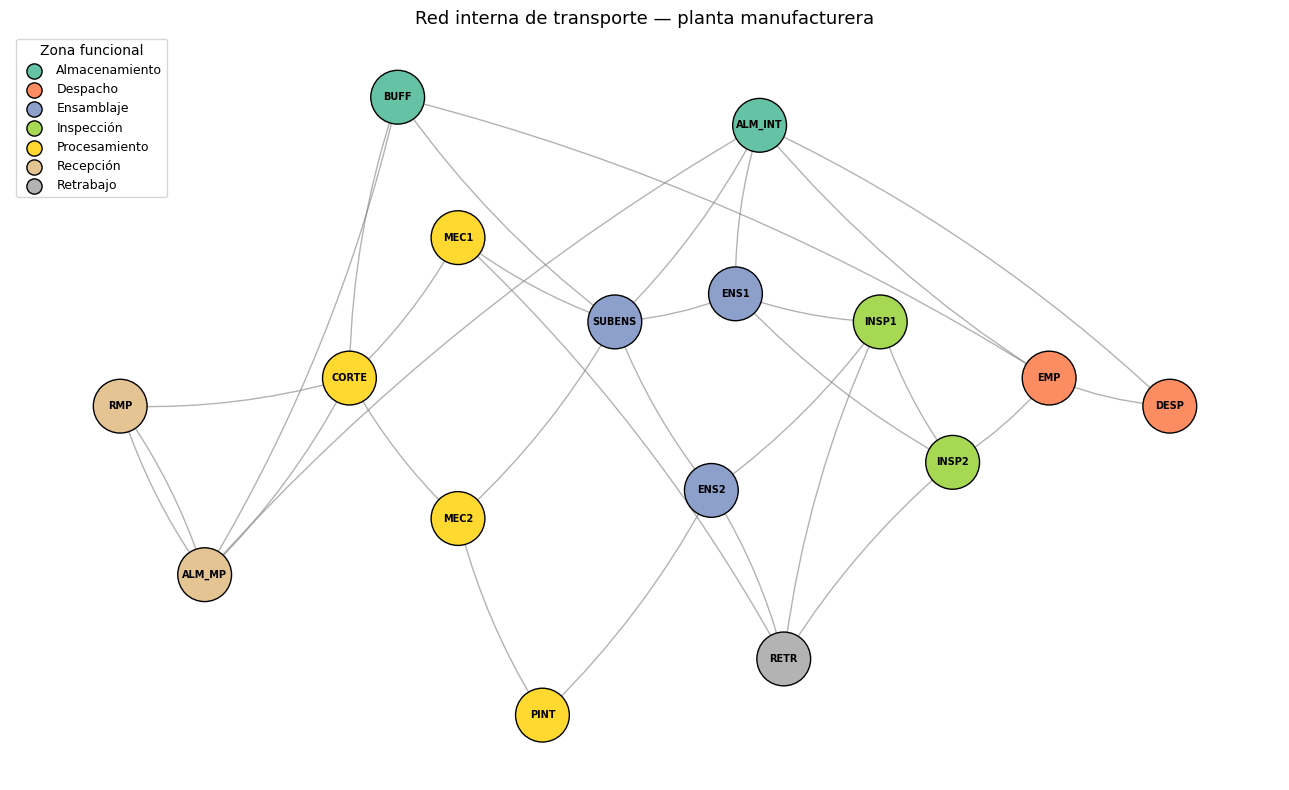

In [6]:
G = nx.DiGraph()
for n in nodos: G.add_node(n)
for _, r in E.iterrows(): G.add_edge(r["origen"], r["destino"], weight=r["La"])

zonas_unicas = sorted(set(zona.values()))
colores = plt.cm.Set2(np.linspace(0, 1, len(zonas_unicas)))
mapa_color = {z: colores[i] for i, z in enumerate(zonas_unicas)}
node_colors = [mapa_color[zona[n]] for n in G.nodes()]

plt.figure(figsize=(13, 8))
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                       arrowsize=15, connectionstyle="arc3,rad=0.08", alpha=0.6)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold")
for z in zonas_unicas:
    plt.scatter([], [], c=[mapa_color[z]], label=z, s=120, edgecolors="black")
plt.legend(title="Zona funcional", loc="upper left", fontsize=9)
plt.title("Red interna de transporte — planta manufacturera", fontsize=13)
plt.axis("off"); plt.tight_layout()
plt.savefig("red_base.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
def dijkstra(ady, origen, destino):
    dist = {n: float("inf") for n in ady}
    prev = {n: None for n in ady}
    dist[origen] = 0.0
    pq = [(0.0, origen)]
    expandidos = 0
    visitados = set()

    while pq:
        d, u = heapq.heappop(pq)
        if u in visitados:
            continue
        visitados.add(u)
        expandidos += 1
        if u == destino:
            break
        for (v, w) in ady[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))

    # reconstruir ruta
    ruta, x = [], destino
    while x is not None:
        ruta.append(x); x = prev[x]
    ruta.reverse()
    if ruta[0] != origen:        # destino inalcanzable
        return None, float("inf"), expandidos
    return ruta, dist[destino], expandidos

In [8]:
def heuristica(i, t):
    (xi,yi),(xt,yt) = pos[i], pos[t]
    return float(np.hypot(xi-xt, yi-yt))

def a_estrella(ady, origen, destino):
    g = {n: float("inf") for n in ady}
    prev = {n: None for n in ady}
    g[origen] = 0.0
    pq = [(heuristica(origen, destino), 0.0, origen)]   # (F, g, nodo)
    expandidos = 0
    visitados = set()

    while pq:
        f, gu, u = heapq.heappop(pq)
        if u in visitados:
            continue
        visitados.add(u)
        expandidos += 1
        if u == destino:
            break
        for (v, w) in ady[u]:
            ng = gu + w
            if ng < g[v]:
                g[v] = ng
                prev[v] = u
                heapq.heappush(pq, (ng + heuristica(v, destino), ng, v))

    ruta, x = [], destino
    while x is not None:
        ruta.append(x); x = prev[x]
    ruta.reverse()
    if ruta[0] != origen:
        return None, float("inf"), expandidos
    return ruta, g[destino], expandidos

In [9]:
def medir_tiempo(func, ady, o, d, repeticiones=2000):
    t0 = time.perf_counter()
    for _ in range(repeticiones):
        func(ady, o, d)
    return (time.perf_counter() - t0) / repeticiones

resultados = []
for (o, d) in pares_OD:
    ruta_dij, len_dij, exp_dij = dijkstra(ady, o, d)
    ruta_ast, len_ast, exp_ast = a_estrella(ady, o, d)
    t_dij = medir_tiempo(dijkstra, ady, o, d)
    t_ast = medir_tiempo(a_estrella, ady, o, d)
    resultados.append({
        "Par": f"{o}→{d}",
        "Long_Dijkstra": round(len_dij,2),
        "Long_A*": round(len_ast,2),
        "Exp_Dijkstra": exp_dij,
        "Exp_A*": exp_ast,
        "t_Dijkstra_us": round(t_dij*1e6, 2),
        "t_A*_us": round(t_ast*1e6, 2),
    })

tabla_rutas = pd.DataFrame(resultados)
print("COMPARACIÓN DIJKSTRA vs A*  (tiempos en microsegundos)\n")
display(tabla_rutas)
tabla_rutas.to_csv("comparacion_rutas.csv", index=False)

# Mostrar las rutas concretas que encontró cada uno
print("\nRUTAS ENCONTRADAS:")
for (o, d) in pares_OD:
    r_dij,_,_ = dijkstra(ady, o, d)
    r_ast,_,_ = a_estrella(ady, o, d)
    print(f"\n{o}→{d}")
    print("  Dijkstra:", " → ".join(r_dij))
    print("  A*      :", " → ".join(r_ast))

COMPARACIÓN DIJKSTRA vs A*  (tiempos en microsegundos)



,Par,Long_Dijkstra,Long_A*,Exp_Dijkstra,Exp_A*,t_Dijkstra_us,t_A*_us
0,RMP→DESP,115.3,115.3,16,13,27.00,93.44
1,CORTE→INSP2,69.4,69.4,10,7,21.57,54.10
2,ALM_MP→EMP,103.0,103.0,14,12,12.81,49.50
3,MEC1→DESP,76.7,76.7,10,8,10.27,33.84
4,RMP→EMP,103.5,103.5,14,11,12.63,46.93



RUTAS ENCONTRADAS:

RMP→DESP
  Dijkstra: RMP → CORTE → MEC1 → SUBENS → ENS1 → INSP2 → EMP → DESP
  A*      : RMP → CORTE → MEC1 → SUBENS → ENS1 → INSP2 → EMP → DESP

CORTE→INSP2
  Dijkstra: CORTE → MEC1 → SUBENS → ENS1 → INSP2
  A*      : CORTE → MEC1 → SUBENS → ENS1 → INSP2

ALM_MP→EMP
  Dijkstra: ALM_MP → CORTE → MEC1 → SUBENS → ENS1 → INSP2 → EMP
  A*      : ALM_MP → CORTE → MEC1 → SUBENS → ENS1 → INSP2 → EMP

MEC1→DESP
  Dijkstra: MEC1 → SUBENS → ENS1 → INSP2 → EMP → DESP
  A*      : MEC1 → SUBENS → ENS1 → INSP2 → EMP → DESP

RMP→EMP
  Dijkstra: RMP → CORTE → MEC1 → SUBENS → ENS1 → INSP2 → EMP
  A*      : RMP → CORTE → MEC1 → SUBENS → ENS1 → INSP2 → EMP


In [10]:
# Admisibilidad: h(i) <= costo real mínimo de i al destino, para todo i y todo destino
admisible_global = True
violaciones = 0
for (o, destino) in pares_OD:
    for n in nodos:
        _, costo_real, _ = dijkstra(ady, n, destino)
        h = heuristica(n, destino)
        if h > costo_real + 1e-9:        # si sobreestima -> no admisible
            admisible_global = False
            violaciones += 1

print("¿Heurística admisible en todos los casos probados?:", admisible_global)
print("Violaciones detectadas:", violaciones)
print("\nRazón: como La >= ||pi - pj|| para toda cinta, la distancia euclidiana")
print("directa al destino nunca supera la longitud real del mejor camino.")
print("Por tanto h(i) nunca sobreestima y A* garantiza el camino óptimo (igual que Dijkstra).")

¿Heurística admisible en todos los casos probados?: True
Violaciones detectadas: 0

Razón: como La >= ||pi - pj|| para toda cinta, la distancia euclidiana
directa al destino nunca supera la longitud real del mejor camino.
Por tanto h(i) nunca sobreestima y A* garantiza el camino óptimo (igual que Dijkstra).


In [11]:
def generar_red(nV, seed):
    r = np.random.default_rng(seed)
    P = {i: (float(r.uniform(0,100)), float(r.uniform(0,100))) for i in range(nV)}

    def d(u, v):
        return float(np.hypot(P[u][0]-P[v][0], P[u][1]-P[v][1]))

    adj = {i: [] for i in range(nV)}
    usadas = set()
    def add_edge(u, v):
        if u != v and (u,v) not in usadas:
            adj[u].append((v, d(u,v) * (1.0 + r.uniform(0.05, 0.25))))
            usadas.add((u,v))

    # 1) ciclo base 0->1->...->(n-1)->0  => garantiza fuerte conexidad
    for i in range(nV):
        add_edge(i, (i+1) % nV)
    # 2) aristas extra hasta |E| ~ 2|V|
    objetivo = 2 * nV
    while len(usadas) < objetivo:
        u, v = int(r.integers(nV)), int(r.integers(nV))
        add_edge(u, v)
    return adj, P

# versiones de Dijkstra y A* que reciben posiciones P (para redes genéricas)
def dijkstra_g(adj, o, d_):
    dist = {n: float("inf") for n in adj}; dist[o] = 0.0
    pq = [(0.0, o)]; exp = 0; vis = set()
    while pq:
        dd, u = heapq.heappop(pq)
        if u in vis: continue
        vis.add(u); exp += 1
        if u == d_: break
        for (v, w) in adj[u]:
            if dd + w < dist[v]:
                dist[v] = dd + w; heapq.heappush(pq, (dist[v], v))
    return dist[d_], exp

def a_estrella_g(adj, P, o, d_):
    def h(i): return float(np.hypot(P[i][0]-P[d_][0], P[i][1]-P[d_][1]))
    g = {n: float("inf") for n in adj}; g[o] = 0.0
    pq = [(h(o), 0.0, o)]; exp = 0; vis = set()
    while pq:
        f, gu, u = heapq.heappop(pq)
        if u in vis: continue
        vis.add(u); exp += 1
        if u == d_: break
        for (v, w) in adj[u]:
            if gu + w < g[v]:
                g[v] = gu + w; heapq.heappush(pq, (g[v] + h(v), g[v], v))
    return g[d_], exp

print("Generador y algoritmos genéricos listos.")

Generador y algoritmos genéricos listos.


In [12]:
tamanos = [20, 40, 80, 160, 320]
n_pares = 30          # pares O-D aleatorios por red, se promedia
filas_esc = []

for nV in tamanos:
    adj, P = generar_red(nV, seed=SEED + nV)
    nE = sum(len(v) for v in adj.values())
    r = np.random.default_rng(SEED + nV)
    pares = [(int(r.integers(nV)), int(r.integers(nV))) for _ in range(n_pares)]

    t_d_tot = t_a_tot = 0.0
    exp_d_tot = exp_a_tot = 0
    REP = 50
    for (o, dd) in pares:
        t0 = time.perf_counter()
        for _ in range(REP): dijkstra_g(adj, o, dd)
        t_d_tot += (time.perf_counter()-t0)/REP
        t0 = time.perf_counter()
        for _ in range(REP): a_estrella_g(adj, P, o, dd)
        t_a_tot += (time.perf_counter()-t0)/REP
        _, ed = dijkstra_g(adj, o, dd)
        _, ea = a_estrella_g(adj, P, o, dd)
        exp_d_tot += ed; exp_a_tot += ea

    filas_esc.append({
        "|V|": nV, "|E|": nE,
        "t_Dijkstra_ms": round(t_d_tot/n_pares*1e3, 4),
        "t_A*_ms":       round(t_a_tot/n_pares*1e3, 4),
        "Exp_Dijkstra":  round(exp_d_tot/n_pares, 1),
        "Exp_A*":        round(exp_a_tot/n_pares, 1),
    })
    print(f"|V|={nV:>3} |E|={nE:>4}  listo")

tabla_esc = pd.DataFrame(filas_esc)
print("\nESCALABILIDAD:")
display(tabla_esc)
tabla_esc.to_csv("escalabilidad.csv", index=False)

|V|= 20 |E|=  40  listo
|V|= 40 |E|=  80  listo
|V|= 80 |E|= 160  listo
|V|=160 |E|= 320  listo
|V|=320 |E|= 640  listo

ESCALABILIDAD:


,|V|,|E|,t_Dijkstra_ms,t_A*_ms,Exp_Dijkstra,Exp_A*
0,20,40,0.0121,0.0362,11.1,9.0
1,40,80,0.0177,0.0470,16.9,13.0
2,80,160,0.0455,0.1246,45.0,36.3
3,160,320,0.0767,0.1847,61.9,45.7
4,320,640,0.1848,0.4384,141.4,104.0


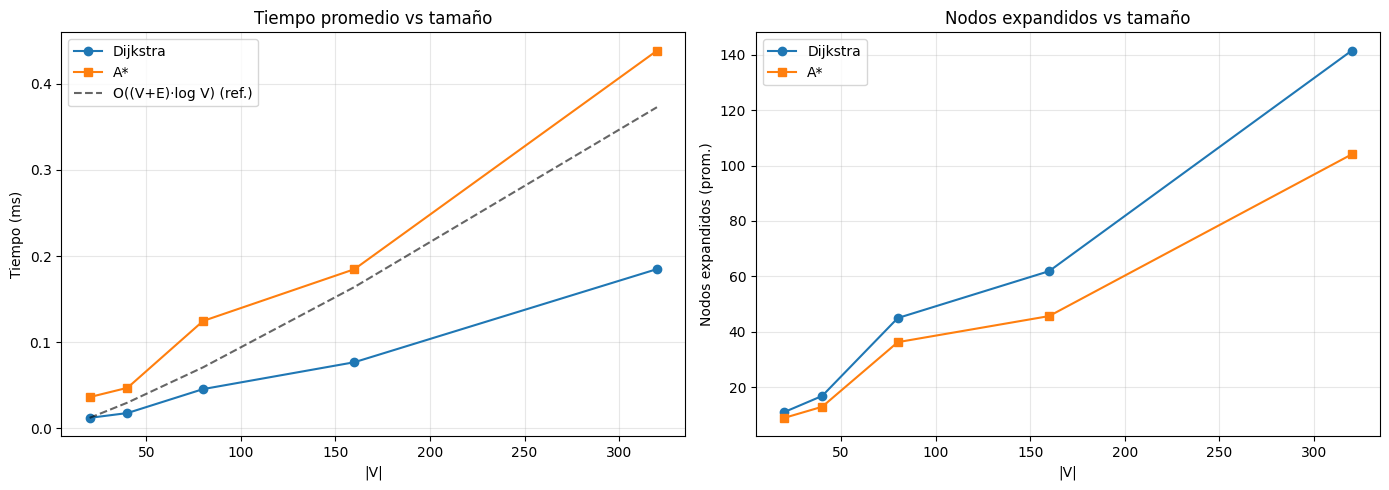

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tabla_esc["|V|"], tabla_esc["t_Dijkstra_ms"], "o-", label="Dijkstra")
ax1.plot(tabla_esc["|V|"], tabla_esc["t_A*_ms"], "s-", label="A*")
# referencia teórica O((V+E)logV), reescalada al primer punto
V = tabla_esc["|V|"].values; Er = tabla_esc["|E|"].values
teorico = (V + Er) * np.log2(V)
teorico = teorico / teorico[0] * tabla_esc["t_Dijkstra_ms"].values[0]
ax1.plot(V, teorico, "k--", alpha=0.6, label="O((V+E)·log V) (ref.)")
ax1.set_xlabel("|V|"); ax1.set_ylabel("Tiempo (ms)")
ax1.set_title("Tiempo promedio vs tamaño"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(tabla_esc["|V|"], tabla_esc["Exp_Dijkstra"], "o-", label="Dijkstra")
ax2.plot(tabla_esc["|V|"], tabla_esc["Exp_A*"], "s-", label="A*")
ax2.set_xlabel("|V|"); ax2.set_ylabel("Nodos expandidos (prom.)")
ax2.set_title("Nodos expandidos vs tamaño"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.savefig("escalabilidad.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
vref, vmax, gamma = 1.0, 3.0, 0.4

def f_v(v, rho):
    return v + gamma*vref*np.log(1 + v/vref) - vmax*(1 - rho**2)

def df_v(v, rho):
    return 1 + gamma/(1 + v/vref)

def newton_raphson(rho, v0, tol=1e-6, max_iter=100):
    v = v0
    for k in range(1, max_iter+1):
        fv = f_v(v, rho)
        if abs(fv) < tol:
            return v, k, abs(fv), True
        dv = df_v(v, rho)
        v_new = v - fv/dv
        if v_new <= 0:                 # corrección de dominio: v > 0
            v_new = v / 2.0            # paso amortiguado hacia el interior del dominio
        v = v_new
    return v, max_iter, abs(f_v(v, rho)), False   # no convergió

In [15]:
filas_nr = []
for _, r in E.iterrows():
    rho = r["Qa"] / r["Ca"]
    v_sol, iters, err, conv = newton_raphson(rho, v0=1.0)
    T = r["La"] / v_sol            # tiempo de recorrido
    filas_nr.append({
        "Cinta": f"{r['origen']}→{r['destino']}",
        "rho": round(rho, 3),
        "v_efectiva": round(v_sol, 4),
        "iters": iters,
        "error_final": f"{err:.2e}",
        "convergio": conv,
        "T_recorrido": round(T, 3),
    })

tabla_nr = pd.DataFrame(filas_nr)
print(f"Cintas resueltas: {len(tabla_nr)} | Todas convergieron: {tabla_nr['convergio'].all()}")
print(f"Iteraciones promedio: {tabla_nr['iters'].mean():.2f}")
display(tabla_nr)
tabla_nr.to_csv("newton_raphson.csv", index=False)

Cintas resueltas: 31 | Todas convergieron: True
Iteraciones promedio: 3.58


,Cinta,rho,v_efectiva,iters,error_final,convergio,T_recorrido
0,RMP→ALM_MP,0.772,0.9449,3,8.79e-10,True,17.674
1,RMP→CORTE,0.837,0.6898,4,9.09e-14,True,32.907
2,ALM_MP→CORTE,0.370,2.1317,4,1.61e-11,True,10.414
3,ALM_MP→BUFF,0.810,0.7986,3,2.04e-07,True,53.596
4,CORTE→MEC1,0.544,1.7135,4,1.36e-12,True,9.279
5,CORTE→MEC2,0.335,2.1981,4,2.13e-11,True,6.688
6,BUFF→CORTE,0.717,1.1517,3,3.61e-08,True,21.533
7,BUFF→SUBENS,0.791,0.8714,3,2.97e-08,True,30.986
8,MEC1→SUBENS,0.557,1.6763,4,9.95e-13,True,10.320
9,MEC2→SUBENS,0.676,1.2981,3,4.31e-07,True,15.561


In [16]:
v0_test = [0.2, 1.0, 5.0]
print("SENSIBILIDAD A LA INICIALIZACIÓN\n")

# Tomamos 3 cintas con distinto rho (baja, media, alta utilización)
muestras = E.assign(rho=E["Qa"]/E["Ca"]).sort_values("rho")
idx = [muestras.index[0], muestras.index[len(muestras)//2], muestras.index[-1]]

filas_sens = []
for i in idx:
    r = E.loc[i]; rho = r["Qa"]/r["Ca"]
    for v0 in v0_test:
        v_sol, iters, err, conv = newton_raphson(rho, v0=v0)
        filas_sens.append({
            "Cinta": f"{r['origen']}→{r['destino']}",
            "rho": round(rho,3), "v0": v0,
            "v_final": round(v_sol,5), "iters": iters, "convergio": conv,
        })

tabla_sens = pd.DataFrame(filas_sens)
display(tabla_sens)
tabla_sens.to_csv("sensibilidad_nr.csv", index=False)

print("\nObservación esperada: para un mismo rho, las tres inicializaciones")
print("convergen al MISMO v_final (la ecuación tiene raíz única en v>0),")
print("variando solo el número de iteraciones.")

SENSIBILIDAD A LA INICIALIZACIÓN



,Cinta,rho,v0,v_final,iters,convergio
0,INSP2→RETR,0.317,0.2,2.22971,4,True
1,INSP2→RETR,0.317,1.0,2.22971,4,True
2,INSP2→RETR,0.317,5.0,2.22971,4,True
3,MEC1→SUBENS,0.557,0.2,1.67634,4,True
4,MEC1→SUBENS,0.557,1.0,1.67634,4,True
5,MEC1→SUBENS,0.557,5.0,1.67634,4,True
6,RMP→CORTE,0.837,0.2,0.68981,4,True
7,RMP→CORTE,0.837,1.0,0.68981,4,True
8,RMP→CORTE,0.837,5.0,0.68981,4,True



Observación esperada: para un mismo rho, las tres inicializaciones
convergen al MISMO v_final (la ecuación tiene raíz única en v>0),
variando solo el número de iteraciones.


In [17]:
!pip install pulp -q
import pulp

filas_esc_mod = []
for _, r in E.iterrows():
    Qa, Ca, La, ca = r["Qa"], r["Ca"], r["La"], r["ca"]

    # Escenario base
    rho0 = Qa / Ca
    v0_sol, _, _, _ = newton_raphson(rho0, v0=1.0)
    T0 = La / v0_sol

    # Escenario modernizado: capacidad +30%
    Ca_mod = 1.3 * Ca
    rho1 = Qa / Ca_mod
    v1_sol, _, _, _ = newton_raphson(rho1, v0=1.0)
    T1 = La / v1_sol

    filas_esc_mod.append({
        "Cinta": f"{r['origen']}→{r['destino']}",
        "Qa": Qa, "ca": ca,
        "rho0": round(rho0,3), "T0": round(T0,4),
        "rho1": round(rho1,3), "T1": round(T1,4),
        "delta_T": round(T0 - T1, 4),
        "QdT": round(Qa*(T0-T1), 3),       # mejora en el indicador si se moderniza
    })

ESC = pd.DataFrame(filas_esc_mod)
print("Escenarios calculados. Verificación T1 < T0 (modernizar siempre reduce tiempo):",
      bool((ESC["T1"] < ESC["T0"]).all()))
display(ESC)
ESC.to_csv("escenarios_modernizacion.csv", index=False)

Escenarios calculados. Verificación T1 < T0 (modernizar siempre reduce tiempo): True


,Cinta,Qa,ca,rho0,T0,rho1,T1,delta_T,QdT
0,RMP→ALM_MP,42.55,1937.0,0.772,17.6740,0.594,10.6732,7.0009,297.886
1,RMP→CORTE,23.01,1685.0,0.837,32.9074,0.644,16.1450,16.7624,385.703
2,ALM_MP→CORTE,30.71,2768.0,0.370,10.4143,0.285,9.7321,0.6823,20.952
3,ALM_MP→BUFF,40.24,3134.0,0.810,53.5961,0.623,29.0371,24.5590,988.254
4,CORTE→MEC1,46.66,2511.0,0.544,9.2794,0.418,7.8271,1.4523,67.763
5,CORTE→MEC2,21.58,2023.0,0.335,6.6876,0.258,6.3345,0.3530,7.618
6,BUFF→CORTE,50.54,2650.0,0.717,21.5326,0.551,14.6602,6.8725,347.334
7,BUFF→SUBENS,77.30,3304.0,0.791,30.9862,0.609,17.7726,13.2137,1021.416
8,MEC1→SUBENS,19.82,1577.0,0.557,10.3201,0.428,8.6108,1.7094,33.880
9,MEC2→SUBENS,21.82,1656.0,0.676,15.5612,0.520,11.3432,4.2180,92.038


In [18]:
def resolver_modelo(B, ESC):
    prob = pulp.LpProblem("Modernizacion", pulp.LpMinimize)
    idx = list(ESC.index)
    y = {i: pulp.LpVariable(f"y_{i}", cat="Binary") for i in idx}

    # Objetivo: min sum Qa * (T0 - dT*y) = const - sum(Qa*dT*y)
    # equivale a MAXIMIZAR la mejora sum(QdT * y); lo dejamos explícito como min del indicador
    prob += pulp.lpSum(ESC.loc[i,"Qa"]*ESC.loc[i,"T0"] - ESC.loc[i,"QdT"]*y[i] for i in idx)
    # Restricción de presupuesto
    prob += pulp.lpSum(ESC.loc[i,"ca"]*y[i] for i in idx) <= B
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    seleccionadas = [i for i in idx if y[i].value() > 0.5]
    costo_usado = sum(ESC.loc[i,"ca"] for i in seleccionadas)
    I0 = sum(ESC.loc[i,"Qa"]*ESC.loc[i,"T0"] for i in idx)
    I_opt = pulp.value(prob.objective)
    return seleccionadas, costo_usado, I0, I_opt, pulp.LpStatus[prob.status]

sel, costo, I0, Iopt, status = resolver_modelo(B0, ESC)

print(f"Estado del solver: {status}")
print(f"Presupuesto B0: {B0:,.2f} u.m.")
print(f"Cintas modernizadas ({len(sel)}):")
for i in sel:
    print(f"   {ESC.loc[i,'Cinta']:<18} ca={ESC.loc[i,'ca']:>8.1f}  mejora QdT={ESC.loc[i,'QdT']:.2f}")
print(f"\nCosto utilizado:      {costo:,.2f} u.m.  ({100*costo/B0:.1f}% del presupuesto)")
print(f"Indicador base  I(0): {I0:,.3f}")
print(f"Indicador opt   I(*): {Iopt:,.3f}")
print(f"Reducción absoluta:   {I0-Iopt:,.3f}")
print(f"Reducción porcentual: {100*(I0-Iopt)/I0:.2f}%")

Estado del solver: Optimal
Presupuesto B0: 22,248.30 u.m.
Cintas modernizadas (9):
   RMP→ALM_MP         ca=  1937.0  mejora QdT=297.89
   RMP→CORTE          ca=  1685.0  mejora QdT=385.70
   ALM_MP→BUFF        ca=  3134.0  mejora QdT=988.25
   BUFF→CORTE         ca=  2650.0  mejora QdT=347.33
   BUFF→SUBENS        ca=  3304.0  mejora QdT=1021.42
   SUBENS→ENS2        ca=  1955.0  mejora QdT=267.38
   SUBENS→ALM_INT     ca=  1995.0  mejora QdT=279.62
   INSP1→RETR         ca=  2936.0  mejora QdT=172.42
   DESP→ALM_INT       ca=  2624.0  mejora QdT=191.00

Costo utilizado:      22,220.00 u.m.  (99.9% del presupuesto)
Indicador base  I(0): 17,909.725
Indicador opt   I(*): 13,958.711
Reducción absoluta:   3,951.014
Reducción porcentual: 22.06%


In [19]:
fracciones = np.arange(0.1, 1.01, 0.1)
filas_sens_B = []

for frac in fracciones:
    B = frac * C_total
    sel, costo, I0, Iopt, status = resolver_modelo(B, ESC)
    filas_sens_B.append({
        "frac_%": int(round(frac*100)),
        "B_disponible": round(B, 1),
        "n_modernizadas": len(sel),
        "costo_usado": round(costo, 1),
        "I_resultante": round(Iopt, 3),
        "reduccion_abs": round(I0 - Iopt, 3),
        "reduccion_%": round(100*(I0 - Iopt)/I0, 2),
    })

tabla_sensB = pd.DataFrame(filas_sens_B)
print(f"Indicador base I(0) = {I0:,.3f}\n")
display(tabla_sensB)
tabla_sensB.to_csv("sensibilidad_presupuesto.csv", index=False)

Indicador base I(0) = 17,909.725



,frac_%,B_disponible,n_modernizadas,costo_usado,I_resultante,reduccion_abs,reduccion_%
0,10,7416.1,2,6438.0,15900.055,2009.670,11.22
1,20,14832.2,6,14705.0,14589.513,3320.212,18.54
2,30,22248.3,9,22220.0,13958.711,3951.014,22.06
3,40,29664.4,13,29630.0,13578.433,4331.292,24.18
4,50,37080.5,15,36638.0,13287.779,4621.946,25.81
5,60,44496.6,18,43257.0,13095.803,4813.922,26.88
6,70,51912.7,20,51102.0,12964.750,4944.975,27.61
7,80,59328.8,24,59108.0,12870.434,5039.291,28.14
8,90,66744.9,27,66506.0,12818.725,5091.000,28.43
9,100,74161.0,31,74161.0,12784.056,5125.669,28.62


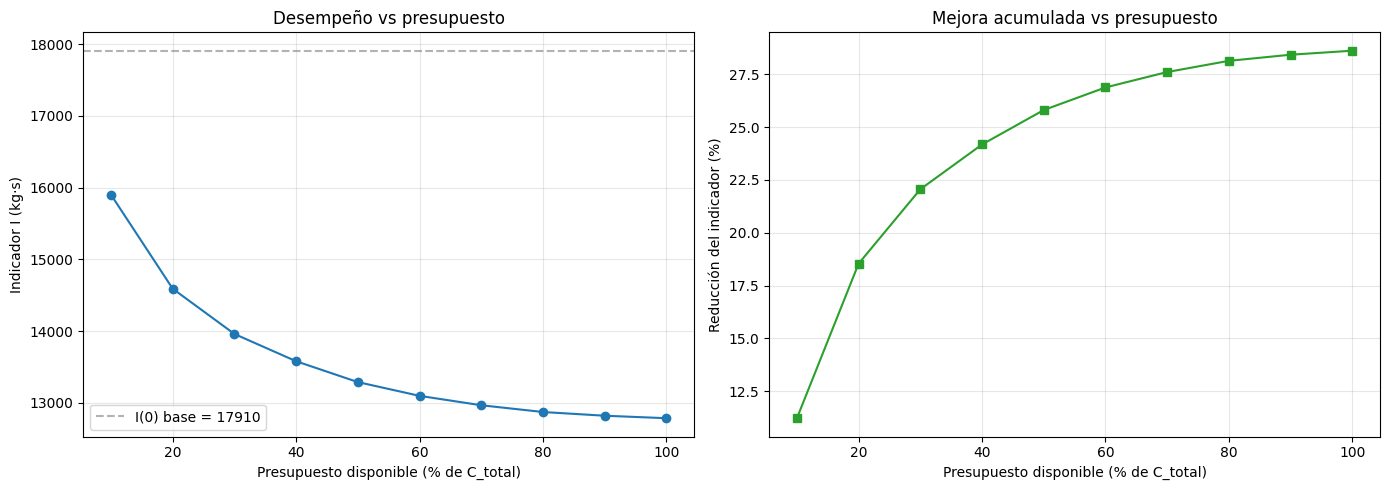


ORDEN DE ENTRADA DE LAS CINTAS AL AUMENTAR EL PRESUPUESTO:
   10% → entra ALM_MP→BUFF        (QdT/ca = 315.333 ×10⁻³)
   10% → entra BUFF→SUBENS        (QdT/ca = 309.145 ×10⁻³)
   20% → entra RMP→ALM_MP         (QdT/ca = 153.787 ×10⁻³)
   20% → entra RMP→CORTE          (QdT/ca = 228.904 ×10⁻³)
   20% → entra BUFF→CORTE         (QdT/ca = 131.069 ×10⁻³)
   20% → entra SUBENS→ALM_INT     (QdT/ca = 140.160 ×10⁻³)
   30% → entra SUBENS→ENS2        (QdT/ca = 136.770 ×10⁻³)
   30% → entra INSP1→RETR         (QdT/ca = 58.726 ×10⁻³)
   30% → entra DESP→ALM_INT       (QdT/ca = 72.789 ×10⁻³)
   40% → entra MEC2→SUBENS        (QdT/ca = 55.579 ×10⁻³)
   40% → entra ENS1→INSP1         (QdT/ca = 60.150 ×10⁻³)
   40% → entra INSP1→INSP2        (QdT/ca = 36.379 ×10⁻³)
   40% → entra RETR→ENS2          (QdT/ca = 51.435 ×10⁻³)
   50% → entra ENS2→INSP1         (QdT/ca = 35.073 ×10⁻³)
   50% → entra EMP→DESP           (QdT/ca = 56.517 ×10⁻³)
   50% → entra ALM_INT→ALM_MP     (QdT/ca = 34.852 ×10⁻³)
   60

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: presupuesto vs indicador
ax1.plot(tabla_sensB["frac_%"], tabla_sensB["I_resultante"], "o-", color="tab:blue")
ax1.axhline(I0, color="gray", ls="--", alpha=0.6, label=f"I(0) base = {I0:.0f}")
ax1.set_xlabel("Presupuesto disponible (% de C_total)")
ax1.set_ylabel("Indicador I (kg·s)")
ax1.set_title("Desempeño vs presupuesto"); ax1.legend(); ax1.grid(alpha=0.3)

# Panel 2: reducción porcentual (muestra rendimientos decrecientes)
ax2.plot(tabla_sensB["frac_%"], tabla_sensB["reduccion_%"], "s-", color="tab:green")
ax2.set_xlabel("Presupuesto disponible (% de C_total)")
ax2.set_ylabel("Reducción del indicador (%)")
ax2.set_title("Mejora acumulada vs presupuesto"); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.savefig("sensibilidad_presupuesto.png", dpi=150, bbox_inches="tight")
plt.show()

# Identificar el orden de entrada de las cintas
print("\nORDEN DE ENTRADA DE LAS CINTAS AL AUMENTAR EL PRESUPUESTO:")
prev = set()
for frac in fracciones:
    B = frac * C_total
    sel, _, _, _, _ = resolver_modelo(B, ESC)
    nuevas = set(sel) - prev
    if nuevas:
        for i in sorted(nuevas):
            print(f"  {int(frac*100):>3}% → entra {ESC.loc[i,'Cinta']:<18} (QdT/ca = {ESC.loc[i,'QdT']/ESC.loc[i,'ca']*1000:.3f} ×10⁻³)")
    prev = set(sel)